# 05. Modelagem, Avaliação e Salvamento do Modelo
# CRISP-DM — Fases 4 e 5: Modelagem e Avaliação

Este notebook consolida as etapas finais do projeto de previsão da nota do IDEB:

1. `carregarDados` — leitura do dataset tratado
2. `separarDados` — divisão 70/15/15 estratificada por bins do IDEB
3. `treinarModelos` — treino de múltiplos algoritmos de regressão
4. `avaliarModelos` — comparação por RMSE, MAE e R²
5. `salvarModelo` — persistência do melhor modelo em `.pkl`
6. `carregarModelo` — validação do modelo salvo
7. `validacaoModelo` — predição final no conjunto cego

**Nota:** O PCA foi descartado nesta versão. A análise exploratória (notebook 02) demonstrou que as variáveis do Censo Escolar são **complementares**, não redundantes — cada uma carrega informação única sobre a escola. Portanto, os modelos são treinados diretamente sobre as features originais, permitindo que algoritmos como Random Forest e Gradient Boosting capturem as interações complexas entre elas.

## 1. Importação das Bibliotecas

In [1]:
# CRISP-DM: preparação de dados fase 3
import pandas as pd
import numpy as np
import pickle
import warnings

warnings.filterwarnings('ignore')

# CRISP-DM: análise de dados fase 3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# CRISP-DM fase 4 — modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# CRISP-DM fase 5 — métricas de regressão
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset Tratado

O dataset `dados_tratados.csv` já passou por todas as etapas de preparação
(limpeza, merge, tratamento de nulos) no notebook anterior. Aqui apenas
carregamos e verificamos sua estrutura.

In [2]:
# CRISP-DM: preparação de dados fase 3
CAMINHO_CSV = '../datasets/dados_tratados.csv'
NOME_MODELO = '../datasets/modelo_ideb.pkl'

def carregarDados(caminho):
    dados = None
    try:
        dados = pd.read_csv(caminho, sep=';', encoding='utf-8-sig')
        print("Dataset carregado com sucesso!")
        print(f"  Registros : {dados.shape[0]:,}")
        print(f"  Colunas   : {dados.shape[1]}")
    except Exception as e:
        print(f"Não foi possível carregar os dados: {e}")
    return dados

df = carregarDados(CAMINHO_CSV)


Dataset carregado com sucesso!
  Registros : 15,925
  Colunas   : 189


## 3. Separação dos Dados — Treino / Teste / Validação

| Conjunto | Proporção | Finalidade |
|---|---|---|
| **Treino** | 70% | Ajuste dos parâmetros dos modelos |
| **Teste** | 15% | Seleção do melhor modelo |
| **Validação** | 15% | Avaliação final — conjunto totalmente cego |

### Estratégia: divisão aleatória estratificada por quantis do IDEB

Para garantir que os três conjuntos tenham **distribuição semelhante do IDEB**, usamos **estratificação por quantis do target**:

1. O IDEB (contínuo) é dividido em até 10 faixas por quantis
2. Cada faixa fica com quantidade semelhante de escolas
3. O `train_test_split` preserva a proporção de cada faixa nos três conjuntos

Isso evita que, por azar, um conjunto fique sistematicamente com escolas de nota alta ou baixa — o que distorceria as métricas de avaliação.

In [3]:
# CRISP-DM fase 4
def criarBinsEstratificacao(y, n_bins=10):
    """Cria faixas por quantis para estratificar um target continuo."""
    q = min(n_bins, y.nunique())
    bins = pd.qcut(y, q=q, labels=False, duplicates='drop')

    # Fallback defensivo para bases pequenas ou com muitos valores repetidos.
    while bins.value_counts().min() < 2 and q > 2:
        q -= 1
        bins = pd.qcut(y, q=q, labels=False, duplicates='drop')

    return bins

# CRISP-DM fase 4
def separarDados(df, n_bins=10):
    """
    Divide os dados em treino (70%), teste (15%) e validação (15%).

    Usa estratificação por quantis do target (IDEB) para garantir que
    a distribuição das notas seja semelhante nos três conjuntos sem criar
    faixas com poucos registros.
    """
    print("Separando os dados de treino, teste e validação...")
    print(f"  Estratégia: estratificação por até {n_bins} quantis do IDEB\n")

    # Separa features (X) e target (y)
    y = df['IDEB_2025']
    X = df.drop(columns=['IDEB_2025'])

    # Cria bins balanceados do target para usar como estratos
    y_bins = criarBinsEstratificacao(y, n_bins=n_bins)

    # 70% treino | 30% restante — com estratificação
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        shuffle=True,
        stratify=y_bins
    )

    # Recalcula bins balanceados para o subconjunto restante
    y_temp_bins = criarBinsEstratificacao(y_temp, n_bins=n_bins)

    # 50% de 30% = 15% teste | 15% validação — com estratificação
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=42,
        shuffle=True,
        stratify=y_temp_bins
    )

    # Relatório de proporções
    print(f"  Treino    : {X_train.shape[0]:>6,} registros ({100 * len(X_train) / len(X):.0f}%)")
    print(f"  Teste     : {X_test.shape[0]:>6,} registros ({100 * len(X_test) / len(X):.0f}%)")
    print(f"  Validação : {X_val.shape[0]:>6,} registros ({100 * len(X_val) / len(X):.0f}%)")

    # Verificação: distribuição do IDEB nos 3 conjuntos
    print("\n  Distribuição do IDEB em cada conjunto:")
    print(f"  {'Conjunto':<12} {'Média':>8} {'Mediana':>9} {'Desvio':>8} {'Mín':>6} {'Máx':>6}")
    print("  " + "-" * 52)
    for nome, y_conj in [
        ("Treino", y_train),
        ("Teste", y_test),
        ("Validação", y_val),
    ]:
        print(
            f"  {nome:<12} "
            f"{y_conj.mean():>8.3f} "
            f"{y_conj.median():>9.3f} "
            f"{y_conj.std():>8.3f} "
            f"{y_conj.min():>6.2f} "
            f"{y_conj.max():>6.2f}"
        )

    return X_train, X_test, X_val, y_train, y_test, y_val

X_train, X_test, X_val, y_train, y_test, y_val = separarDados(df)


Separando os dados de treino, teste e validação...
  Estratégia: estratificação por até 10 quantis do IDEB

  Treino    : 11,147 registros (70%)
  Teste     :  2,389 registros (15%)
  Validação :  2,389 registros (15%)

  Distribuição do IDEB em cada conjunto:
  Conjunto        Média   Mediana   Desvio    Mín    Máx
  ----------------------------------------------------
  Treino          4.418     4.400    0.705   0.80   7.80
  Teste           4.418     4.400    0.702   2.00   7.90
  Validação       4.424     4.400    0.708   2.20   8.10


## 4. Treinamento dos Modelos

Cada algoritmo de regressão é treinado diretamente sobre as features originais.

**Por que não usar PCA?**
- O PCA busca redundância (variáveis correlacionadas) para comprimir a informação
- As variáveis do Censo Escolar são **complementares**, não redundantes
- Aplicar PCA descartaria informação única de cada variável, prejudicando a previsão
- Algoritmos baseados em árvores (Random Forest, Gradient Boosting) lidam naturalmente com muitas features e capturam interações complexas


In [4]:
# CRISP-DM fase 4
def treinarModelos(X_train, y_train):
    print("Treinando modelos de IA...\n")

    # Lista de algoritmos de regressão
    listaAlgoritmos = [
        ("Regressão Linear", LinearRegression()),
        ("Ridge (L2)", Ridge(alpha=1.0)),
        (
            "Random Forest",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        ),
        (
            "Gradient Boosting",
            GradientBoostingRegressor(
                n_estimators=100,
                random_state=42
            )
        ),
        (
            "KNN Regressor",
            KNeighborsRegressor(
                n_neighbors=10
            )
        ),
        (
            "SVR",
            SVR(
                kernel='rbf',
                C=1.0
            )
        ),
        (
            "MLP Regressor",
            MLPRegressor(
                hidden_layer_sizes=(100,),
                max_iter=500,
                random_state=42
            )
        ),
    ]

    listaModelos = []

    for nome, algoritmo in listaAlgoritmos:
        try:
            algoritmo.fit(X_train, y_train)
            listaModelos.append((nome, algoritmo))
            print(f"  ✅ {nome} treinado.")
        except Exception as e:
            print(f"  ❌ {nome} falhou: {e}")
            continue

    print(f"\nTotal de modelos treinados: {len(listaModelos)}")

    return listaModelos

listaModelos = treinarModelos(X_train, y_train)


Treinando modelos de IA...

  ✅ Regressão Linear treinado.
  ✅ Ridge (L2) treinado.
  ✅ Random Forest treinado.
  ✅ Gradient Boosting treinado.
  ✅ KNN Regressor treinado.
  ✅ SVR treinado.
  ✅ MLP Regressor treinado.

Total de modelos treinados: 7


## 5. Avaliação dos Modelos — Conjunto de Teste

**Métricas:**

- **MSE / EMQ** — Erro Médio Quadrático *(penaliza erros grandes)*
- **RMSE** — Raiz do MSE *(na mesma escala do IDEB, 0–10)*
- **MAE** — Erro Absoluto Médio
- **R²** — Proporção da variância do IDEB explicada pelo modelo


In [5]:
# CRISP-DM fase 5
def avaliarModelos(listaModelos, X_test, y_test):
    listaResultados = []

    print("-" * 72)
    print(
        f"  {'Modelo':<22}  "
        f"{'RMSE':>8}  "
        f"{'MAE':>8}  "
        f"{'R²':>8}  "
        f"{'MSE':>10}"
    )
    print("-" * 72)

    for nome, modelo in listaModelos:
        y_pred = modelo.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        listaResultados.append({
            "Modelo": nome,
            "MSE (EMQ)": round(mse, 4),
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),
            "R²": round(r2, 4)
        })

        print(
            f"  {nome:<22}  "
            f"{rmse:>8.4f}  "
            f"{mae:>8.4f}  "
            f"{r2:>8.4f}  "
            f"{mse:>10.4f}"
        )

    print("-" * 72)

    df_resultados = (
        pd.DataFrame(listaResultados)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    melhor_rmse = df_resultados.iloc[0]["RMSE"]
    melhor_nome = df_resultados.iloc[0]["Modelo"]

    print(f"\nMelhor RMSE  : {melhor_rmse:.4f}")
    print(f"Melhor Modelo: {melhor_nome}")

    return df_resultados, melhor_nome

df_resultados, melhor_nome = avaliarModelos(listaModelos, X_test, y_test)


------------------------------------------------------------------------
  Modelo                      RMSE       MAE        R²         MSE
------------------------------------------------------------------------
  Regressão Linear          0.5643    0.4327    0.3531      0.3184
  Ridge (L2)                0.5642    0.4327    0.3532      0.3184
  Random Forest             0.5138    0.3910    0.4637      0.2640
  Gradient Boosting         0.5311    0.4051    0.4270      0.2821
  KNN Regressor             0.5988    0.4615    0.2717      0.3585
  SVR                       0.5831    0.4424    0.3092      0.3400
  MLP Regressor             0.6529    0.4938    0.1340      0.4263
------------------------------------------------------------------------

Melhor RMSE  : 0.5138
Melhor Modelo: Random Forest


## 6. Comparação Visual dos Modelos

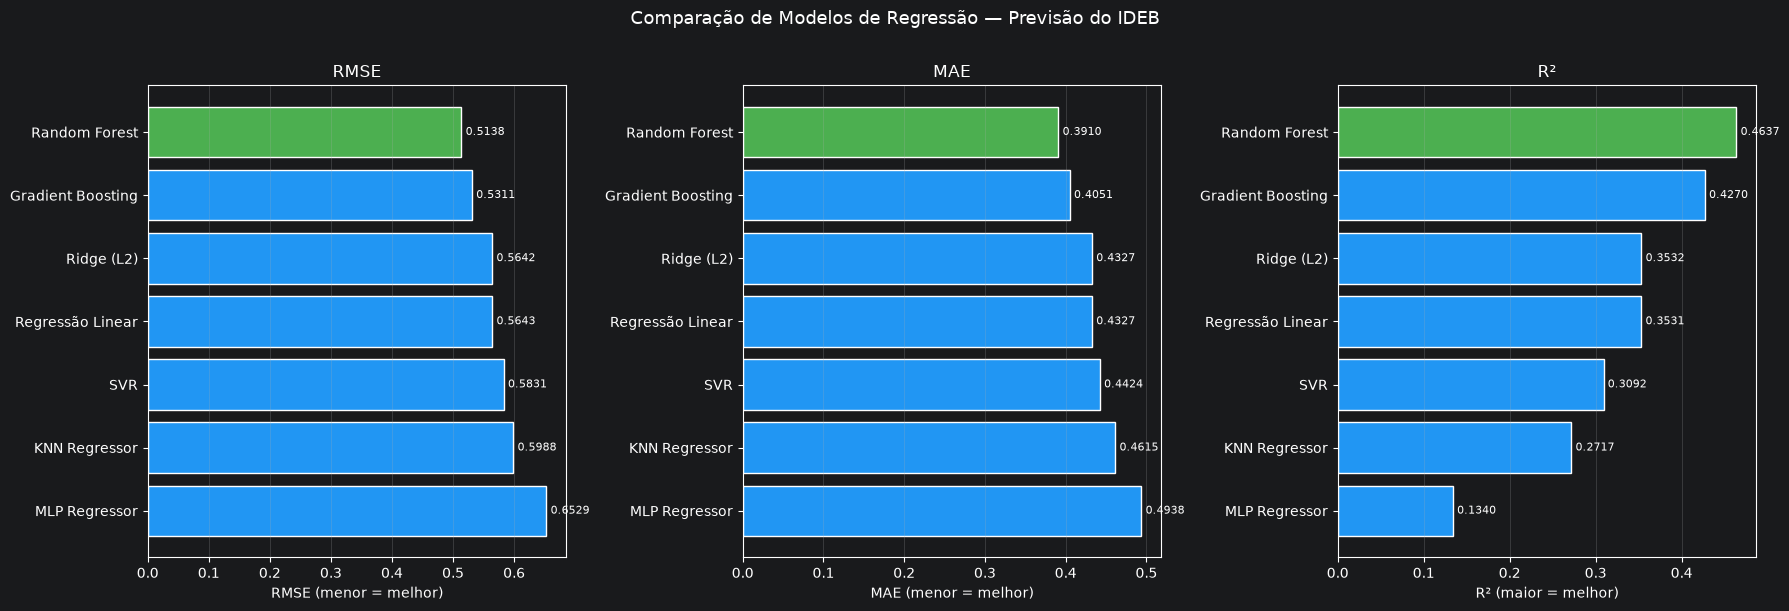

Verde = melhor modelo | Azul = demais


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos = df_resultados["Modelo"].tolist()
rmse_vals = df_resultados["RMSE"].tolist()
mae_vals = df_resultados["MAE"].tolist()
r2_vals = df_resultados["R²"].tolist()

cores = [
    '#4CAF50' if m == melhor_nome else '#2196F3'
    for m in modelos
]

for ax, vals, label, titulo in zip(
    axes,
    [rmse_vals, mae_vals, r2_vals],
    [
        'RMSE (menor = melhor)',
        'MAE (menor = melhor)',
        'R² (maior = melhor)'
    ],
    ['RMSE', 'MAE', 'R²']
):
    bars = ax.barh(
        modelos,
        vals,
        color=cores,
        edgecolor='white'
    )

    ax.set_xlabel(label, fontsize=10)
    ax.set_title(titulo, fontsize=12)
    ax.bar_label(
        bars,
        fmt='%.4f',
        padding=3,
        fontsize=8
    )
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    'Comparação de Modelos de Regressão — Previsão do IDEB',
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.savefig(
    '../imagens/comparacao_modelos.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("Verde = melhor modelo | Azul = demais")


## 7. Salvamento do Melhor Modelo

O modelo com melhor RMSE no conjunto de teste é salvo em formato `.pkl`
para uso futuro sem necessidade de retreinamento.


In [7]:
# CRISP-DM fase 5
def salvarModelo(nomeArquivo, listaModelos, melhorNome):
    melhor_modelo = dict(listaModelos)[melhorNome]

    with open(nomeArquivo, 'wb') as f:
        pickle.dump(melhor_modelo, f)

    print(f"Modelo '{melhorNome}' salvo em: {nomeArquivo}")

    return melhor_modelo

melhor_modelo = salvarModelo(NOME_MODELO, listaModelos, melhor_nome)


Modelo 'Random Forest' salvo em: ../datasets/modelo_ideb.pkl


## 8. Carregamento do Modelo Salvo

In [8]:
# CRISP-DM fase 5
def carregarModelo(nomeArquivo):
    modelo = None
    try:
        with open(nomeArquivo, 'rb') as f:
            modelo = pickle.load(f)
        print(f"Modelo carregado com sucesso: {nomeArquivo}")
    except Exception as e:
        print(f"Erro ao carregar modelo: {e}")
    return modelo

modeloCarregado = carregarModelo(NOME_MODELO)


Modelo carregado com sucesso: ../datasets/modelo_ideb.pkl


## 9. Validação Final — Conjunto Cego

O conjunto de validação é **totalmente cego** — nunca foi visto pelo modelo
durante treino ou seleção. É a avaliação mais honesta de generalização.


  VALIDAÇÃO FINAL — Random Forest
  MSE (EMQ) : 0.2695
  RMSE      : 0.5191  → erro médio de 0.52 pts no IDEB
  MAE       : 0.3918
  R²        : 0.4614

Predições (primeiros 10 valores):
  Real   : [np.float64(4.3), np.float64(5.0), np.float64(4.7), np.float64(5.0), np.float64(4.2), np.float64(5.5), np.float64(4.3), np.float64(4.3), np.float64(5.4), np.float64(4.4)]
  Predito: [np.float64(5.11), np.float64(4.59), np.float64(4.94), np.float64(4.4), np.float64(4.7), np.float64(5.19), np.float64(4.85), np.float64(4.03), np.float64(4.69), np.float64(4.75)]


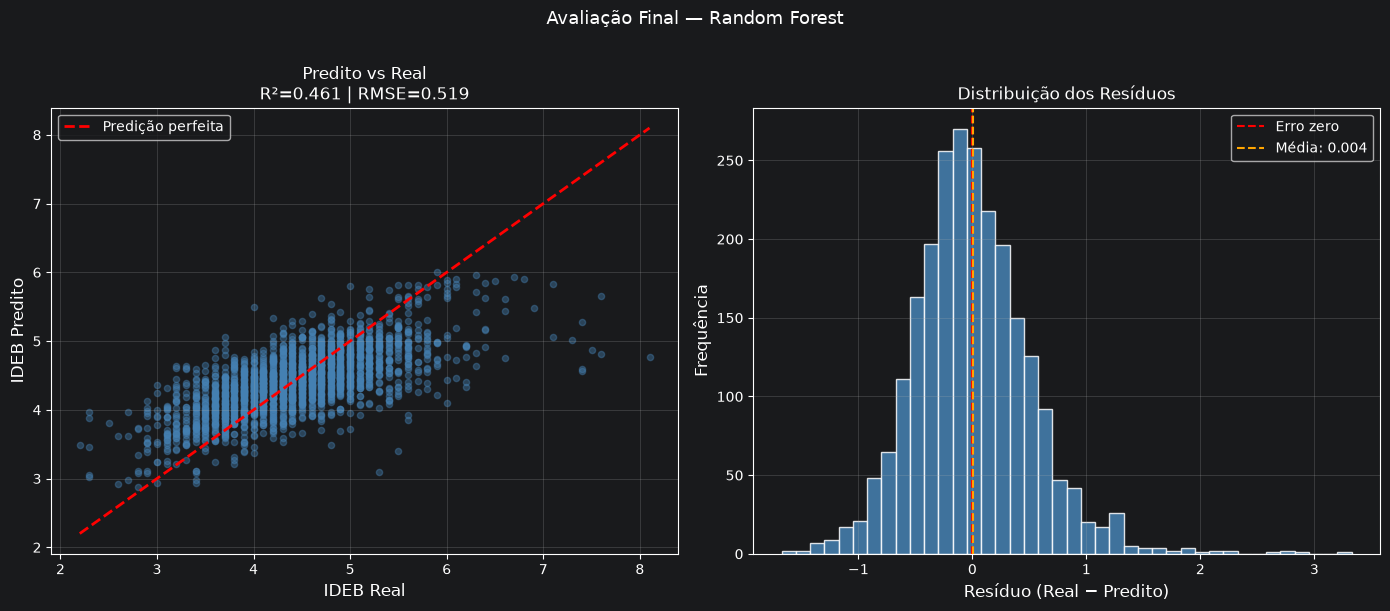

In [9]:
# CRISP-DM fase 5
def validacaoModelo(modelo, X_validacao, y_validacao, melhorNome):
    y_pred = modelo.predict(X_validacao)

    mse_val = mean_squared_error(y_validacao, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_validacao, y_pred)
    r2_val = r2_score(y_validacao, y_pred)

    print("=" * 58)
    print(f"  VALIDAÇÃO FINAL — {melhorNome}")
    print("=" * 58)
    print(f"  MSE (EMQ) : {mse_val:.4f}")
    print(
        f"  RMSE      : {rmse_val:.4f}  "
        f"→ erro médio de {rmse_val:.2f} pts no IDEB"
    )
    print(f"  MAE       : {mae_val:.4f}")
    print(f"  R²        : {r2_val:.4f}")
    print("=" * 58)

    print("\nPredições (primeiros 10 valores):")
    print(f"  Real   : {list(np.round(y_validacao.values[:10], 2))}")
    print(f"  Predito: {list(np.round(y_pred[:10], 2))}")

    # Gráficos de avaliação
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].scatter(
        y_validacao,
        y_pred,
        alpha=0.4,
        color='steelblue',
        s=20
    )
    axes[0].plot(
        [y_validacao.min(), y_validacao.max()],
        [y_validacao.min(), y_validacao.max()],
        'r--',
        linewidth=2,
        label='Predição perfeita'
    )
    axes[0].set_xlabel('IDEB Real', fontsize=12)
    axes[0].set_ylabel('IDEB Predito', fontsize=12)
    axes[0].set_title(
        f'Predito vs Real\nR²={r2_val:.3f} | RMSE={rmse_val:.3f}',
        fontsize=12
    )
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    residuos = y_validacao - y_pred
    axes[1].hist(
        residuos,
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Erro zero')
    axes[1].axvline(
        residuos.mean(),
        color='orange',
        linestyle='--',
        label=f'Média: {residuos.mean():.3f}'
    )
    axes[1].set_xlabel('Resíduo (Real − Predito)', fontsize=12)
    axes[1].set_ylabel('Frequência', fontsize=12)
    axes[1].set_title('Distribuição dos Resíduos', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Avaliação Final — {melhorNome}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(
        '../imagens/validacao_final.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

    return y_pred

y_pred_val = validacaoModelo(modeloCarregado, X_val, y_val, melhor_nome)


---
## Conclusão

| Etapa | Resultado |
|---|---|
| Divisão dos dados | 70% treino / 15% teste / 15% validação — **aleatória e estratificada** por bins do IDEB |
| Algoritmos testados | Regressão Linear, Ridge, Random Forest, Gradient Boosting, KNN, SVR, MLP |
| Estratégia | Treino direto sobre features originais (sem PCA) |
| Melhor modelo | Ver seção 5 — menor RMSE no conjunto de teste |
| Validação final | Ver seção 9 — avaliação no conjunto cego |
| Modelo salvo | `../datasets/modelo_ideb.pkl` |

### Sobre a estratégia de divisão dos dados

A divisão foi feita de forma **aleatória e estratificada por quantis do IDEB**. Isso garante que:

1. **Aleatoriedade:** cada escola tem chance igual de cair em qualquer conjunto (`shuffle=True`)
2. **Balanceamento:** a distribuição do IDEB é semelhante nos três conjuntos, evitando viés e faixas com poucos registros
3. **Reprodutibilidade:** a seed `random_state=42` garante que a divisão seja sempre a mesma

A estratificação por quantis é uma técnica adequada para problemas de **regressão**, onde o target é contínuo e não existem classes naturais para estratificar.

### Sobre a escolha de não usar PCA

O PCA foi descartado porque:
1. As variáveis do Censo Escolar são **complementares**, não redundantes
2. O Teste de Bartlett indicou ausência de correlação suficiente para compressão eficiente
3. Modelos como Random Forest e Gradient Boosting lidam bem com alta dimensionalidade
4. A interpretabilidade das features originais é preservada

### Limitações e próximos passos

- Ajuste de hiperparâmetros (Grid Search / Randomized Search) pode melhorar o desempenho
- Fatores socioeconômicos externos ao Censo Escolar aumentariam o R²
- O modelo pode ser implantado em uma aplicação simples para uso pelos gestores
